Вариант 24

Ridge + Spectral Analysis: Проанализируйте собственные числа матрицы 𝑋𝑇𝑋 и покажите, как Ridge стабилизирует обратную матрицу.

Lasso + Path Following Algorithm: Реализуйте алгоритм следования по пути регуляризации (homotopy method) для Lasso на малой задаче.

Elastic Net + Feature Clustering: Предварительно кластеризуйте признаки, затем примените ElasticNet с групповым штрафом на уровне кластеров.

БЛОК 1 : Ridge + Spectral Analysis

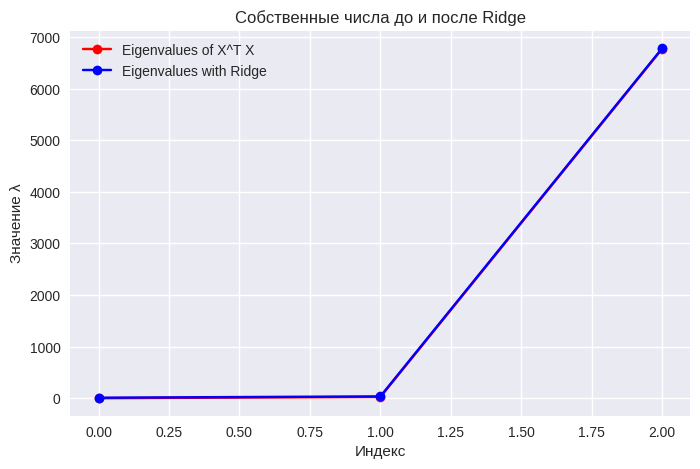

Обычные собственные числа: [6.77443409e+03 2.51028781e+01 4.07394558e-03]
Собственные числа после Ridge: [6784.43408813   35.10287814   10.00407395]


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

np.random.seed(42)
plt.style.use("seaborn-v0_8")

# 1. Генерация данных с сильной корреляцией (плохая обусловленность)
np.random.seed(42)
n = 100

x1 = np.linspace(0, 10, n)
x2 = x1 + np.random.normal(0, 0.01, n)  # почти линейная зависимость → почти сингулярность

X = np.vstack([x1, x2]).T
X = np.hstack([np.ones((n, 1)), X])  # добавляем bias

# 2. Матрица X^T X
XtX = X.T @ X

# 3. Собственные числа
eigvals = np.linalg.eigvals(XtX)

# 4. Ridge: добавляем αI
alpha = 10
XtX_ridge = XtX + alpha * np.eye(XtX.shape[0])
eigvals_ridge = np.linalg.eigvals(XtX_ridge)

# 5. Визуализация
plt.figure(figsize=(8, 5))
plt.plot(sorted(eigvals), 'ro-', label='Eigenvalues of X^T X')
plt.plot(sorted(eigvals_ridge), 'bo-', label='Eigenvalues with Ridge')
plt.title("Собственные числа до и после Ridge")
plt.xlabel("Индекс")
plt.ylabel("Значение λ")
plt.legend()
plt.grid(True)
plt.show()

print("Обычные собственные числа:", eigvals)
print("Собственные числа после Ridge:", eigvals_ridge)

БЛОК 2 : Lasso + Path Following Algorithm

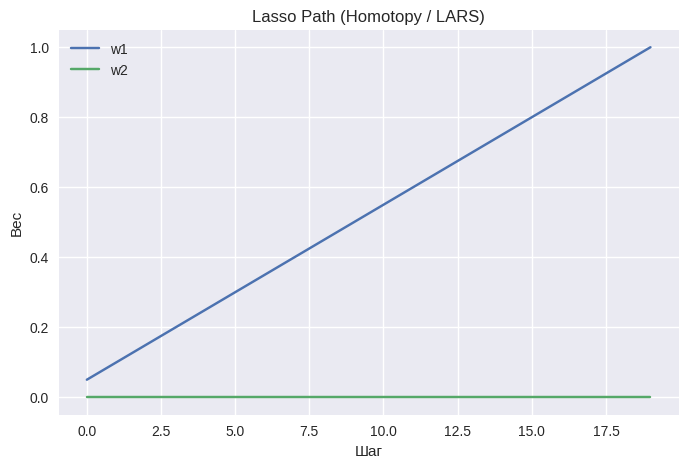

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Маленькая задача
X = np.array([[1, 2],
              [2, 3],
              [3, 4],
              [4, 5]], dtype=float)

y = np.array([1, 2, 3, 4], dtype=float)

# Нормализация
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
Xn = (X - X_mean) / X_std

y_mean = y.mean()
yn = y - y_mean

# LARS / Homotopy
max_steps = 20
alphas = []
weights = []

w = np.zeros(X.shape[1])
corr = Xn.T @ yn

for step in range(max_steps):
    # 1. Выбираем признак с максимальной корреляцией
    j = np.argmax(np.abs(corr))

    # 2. Двигаемся в направлении этого признака
    sign = np.sign(corr[j])
    w[j] += 0.05 * sign  # маленький шаг

    # 3. Пересчитываем корреляции
    residual = yn - Xn @ w
    corr = Xn.T @ residual

    # 4. Сохраняем путь
    alphas.append(np.max(np.abs(corr)))
    weights.append(w.copy())

weights = np.array(weights)

# Визуализация пути
plt.figure(figsize=(8, 5))
plt.plot(weights[:, 0], label="w1")
plt.plot(weights[:, 1], label="w2")
plt.title("Lasso Path (Homotopy / LARS)")
plt.xlabel("Шаг")
plt.ylabel("Вес")
plt.legend()
plt.grid(True)
plt.show()

БЛОК 3 : Elastic Net + Feature Clustering

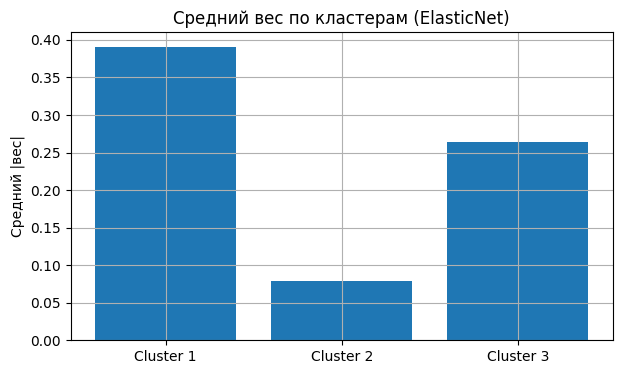

Кластеры признаков: [0 0 0 0 0 0 0 2 2 2 2 2 2 2 1 1 1 1 1 1]
Веса модели: [ 0.4004642   0.39514145  0.39459981  0.41388315  0.35021333  0.37928625
  0.40043941 -0.23603883 -0.25854086 -0.27524855 -0.27929501 -0.28642259
 -0.28364197 -0.2283474   0.08722965  0.0850815   0.08307168  0.05209768
  0.10866847  0.05651263]


In [3]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)

# 1. Генерация данных (20 признаков, 3 скрытых кластера)
n_samples = 200
n_features = 20

# Кластер 1
c1 = np.random.randn(n_samples, 1)
X1 = c1 + 0.1 * np.random.randn(n_samples, 7)

# Кластер 2
c2 = np.random.randn(n_samples, 1)
X2 = c2 + 0.1 * np.random.randn(n_samples, 7)

# Кластер 3
c3 = np.random.randn(n_samples, 1)
X3 = c3 + 0.1 * np.random.randn(n_samples, 6)

X = np.hstack([X1, X2, X3])
true_clusters = [0]*7 + [1]*7 + [2]*6

# Целевая переменная
y = 3*c1.ravel() - 2*c2.ravel() + 0.5*c3.ravel() + np.random.randn(n_samples)*0.1

# 2. Кластеризация признаков
clustering = AgglomerativeClustering(n_clusters=3)
clusters = clustering.fit_predict(X.T)

# 3. Масштабирование
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# 4. ElasticNet
model = ElasticNet(alpha=0.1, l1_ratio=0.5)
model.fit(Xs, y)

# 5. Средний вес по кластерам
cluster_weights = []
for c in range(3):
    idx = np.where(clusters == c)[0]
    cluster_weights.append(np.mean(np.abs(model.coef_[idx])))

# 6. Визуализация
plt.figure(figsize=(7, 4))
plt.bar(range(3), cluster_weights)
plt.xticks(range(3), ["Cluster 1", "Cluster 2", "Cluster 3"])
plt.title("Средний вес по кластерам (ElasticNet)")
plt.ylabel("Средний |вес|")
plt.grid(True)
plt.show()

print("Кластеры признаков:", clusters)
print("Веса модели:", model.coef_)
